# SHAP for MRS discharge 3-5 for untreated patients

In [1]:
import lightgbm as lgb
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import shap

from sklearn.metrics import accuracy_score, recall_score, roc_auc_score, confusion_matrix
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

## Define features to use



In [2]:
features = [
    'stroke_team',
    'age',
    'male',
    'ethnicity',
    'infarction',
    'arrive_by_ambulance',
    'onset_to_arrival_time',
    'arrival_to_scan_time',
    'congestive_heart_failure',
    'hypertension',
    'atrial_fibrillation',
    'diabetes',
    'prior_stroke_tia',
    'afib_anticoagulant',
    'any_afib_diagnosis',
    'prior_disability',
    'stroke_severity',
]

## Load and prepare data

In [3]:
all_data = pd.read_csv("../../data/sam3/cleaned_data.csv", low_memory=False)

In [4]:
# Filter data to teams with at least 300 admissions and 10 thrombolysis use
keep = []
groups = all_data.groupby('stroke_team') # creates a new object of groups of data

for index, group_df in groups: # each group has an index and a dataframe of data
    
    # Skip if total admission less than 300 or total thrombolysis < 10
    if (group_df.shape[0] < 300) or (group_df['thrombolysis'].sum() < 10):
        continue
    
    else: 
        keep.append(group_df)

# Concatenate output
data = pd.DataFrame()
data = pd.concat(keep)

n_patients_after_admission_restrictions = data.shape[0]
# Print the number of patients before and after applying the admission restrictions
print(f"Number of patients before admission restrictions: {all_data.shape[0]}")
print(f"Number of patients after admission restrictions: {n_patients_after_admission_restrictions}")
print("Difference in number of patients: ", all_data.shape[0] - n_patients_after_admission_restrictions)

Number of patients before admission restrictions: 452863
Number of patients after admission restrictions: 452115
Difference in number of patients:  748


In [5]:
# Drop any rows with no dicharge_disability value
data = data.dropna(subset=['discharge_disability'])

# Print the number of patients before and after dropping rows with missing discharge_disability
print(f"Number of patients before dropping rows with missing discharge_disability: {n_patients_after_admission_restrictions}")
print(f"Number of patients after dropping rows with missing discharge_disability: {data.shape[0]}")
print("Difference in number of patients: ", n_patients_after_admission_restrictions - data.shape[0])

Number of patients before dropping rows with missing discharge_disability: 452115
Number of patients after dropping rows with missing discharge_disability: 437882
Difference in number of patients:  14233


In [6]:
data['discharge_disability_3_to_5'] = ((data['discharge_disability'] >= 3) & (data['discharge_disability'] <= 5)).astype(int)

# Create  80:20 train-test split
X = data[features]
y = data['discharge_disability_3_to_5']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
# Remove rows where thrombolysis or thrombectomy is 1
data = data[(data['thrombolysis'] != 1) & (data['thrombectomy'] != 1)]

In [8]:
categorical_features = [
    'stroke_team',
    'ethnicity',
]

# Ensure categorical columns are true pandas categorical dtype for XGBoost
for col in categorical_features:
    X_train[col] = X_train[col].astype("category")
    X_test[col] = pd.Categorical(X_test[col], categories=X_train[col].cat.categories)

## Fit model and get accuracy

In [9]:
# Fit XGBoost model, with categorical features specified
model = XGBClassifier(
    enable_categorical=True,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    seed=42
)

# Fit model
model.fit(X_train, y_train)
# Get ROC AUC for predicted categories
y_proba = model.predict_proba(X_test)
roc_auc = roc_auc_score(y_test, y_proba[:, 1])
print(f"ROC AUC score for the model on the test set: {roc_auc:.4f}")

# Get accuracy, sensitivity, specificity, and balanced accuracy for predicted categories
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
sensitivity = recall_score(y_test, y_pred)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
specificity = tn / (tn + fp)
balanced_accuracy = (sensitivity + specificity) / 2

# Print the metrics
print(f"Accuracy: {accuracy:.4f}")
print(f"Sensitivity: {sensitivity:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"Balanced Accuracy: {balanced_accuracy:.4f}")

ROC AUC score for the model on the test set: 0.7913
Accuracy: 0.7146
Sensitivity: 0.7343
Specificity: 0.7002
Balanced Accuracy: 0.7172


## Get SHAP values and plot

In [10]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

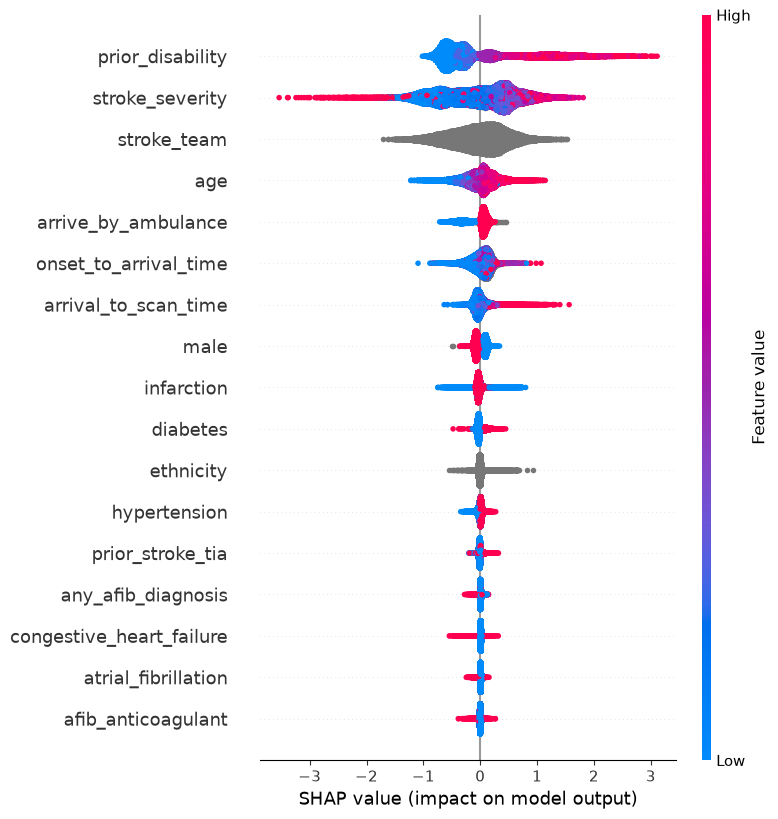

In [11]:
# Plot a beeswarm plot of SHAP values for the test set
fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="dot",
    max_display=X_test.shape[1],
    show=False)
plt.tight_layout()
plt.savefig("./output/shap_untreated_patients_mrs_3_to_5.png", dpi=300, bbox_inches="tight")
plt.show()

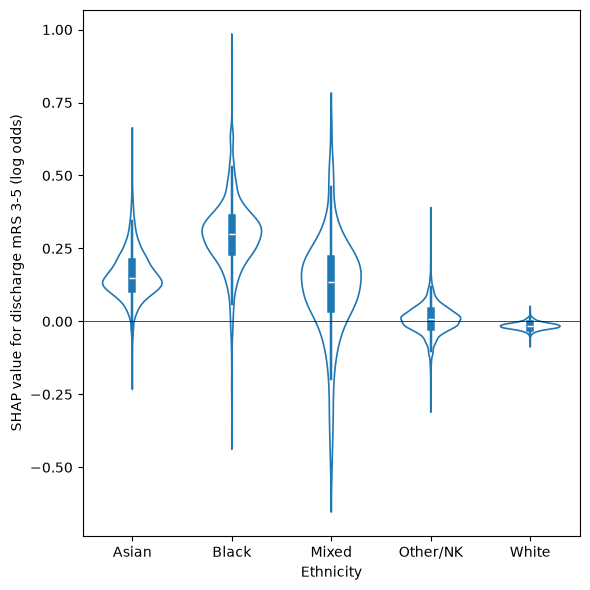

In [12]:
# Get feature and shap values for the ethncity feature
eth_idx = list(X.columns).index("ethnicity")
feature_values = X_test.iloc[:, eth_idx]
shap_values_ethnicity = shap_values[:, eth_idx] if isinstance(shap_values, np.ndarray) else shap_values[1][:, eth_idx]

# Plot as sns violin plot
plt.figure(figsize=(6, 6))
sns.violinplot(x=feature_values,
               y=shap_values_ethnicity,
               width=0.6,
               fill=False,
               inner="box",
               density_norm="width",
               linewidth=1.2)

plt.xlabel("Ethnicity")
plt.ylabel("SHAP value for discharge mRS 3-5 (log odds)")

# Add a line at y=0
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.savefig("./output/shap_untreated_patients_mrs_3_to_5_ethnicity.png", dpi=300, bbox_inches="tight")
plt.show()

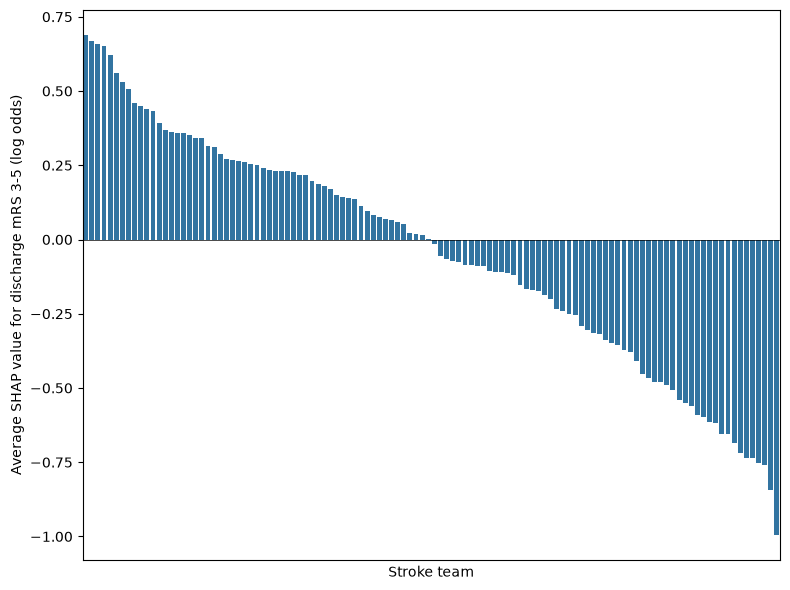

In [13]:
# Get SHAP values for the stroke_team feature, average for each team
stroke_team_idx = list(X.columns).index("stroke_team")
feature_values = X_test.iloc[:, stroke_team_idx]
shap_values_stroke_team = shap_values[:, stroke_team_idx] if isinstance(shap_values, np.ndarray) else shap_values[1][:, stroke_team_idx]

# Average SHAP values for each stroke team
stroke_team_shap_df = pd.DataFrame({
    'stroke_team': feature_values,
    'shap_value': shap_values_stroke_team
})
stroke_team_shap_df = stroke_team_shap_df.groupby('stroke_team').mean().reset_index()

# Sort by SHAP value
stroke_team_shap_df = stroke_team_shap_df.sort_values(by='shap_value', ascending=False)
team_order = (
    stroke_team_shap_df
    .groupby("stroke_team")["shap_value"]
    .mean()
    .sort_values(ascending=False)
    .index
)

# Plot as sns bar plot
plt.figure(figsize=(8, 6))
ax = sns.barplot(
    data=stroke_team_shap_df,
    order=team_order,
    x="stroke_team",
    y="shap_value",
)

# Remove the individual tick labels (team names) and tick marks
ax.set_xticks([])

plt.xlabel("Stroke team")
plt.ylabel("Average SHAP value for discharge mRS 3-5 (log odds)")
#plt.title("Average SHAP Values by Stroke Team")
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.savefig("./output/shap_untreated_patients_mrs_3_to_5_stroke_team.png", dpi=300, bbox_inches="tight")
plt.show()